In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, f1_score,
    recall_score, precision_score
)
from xgboost import XGBClassifier

In [21]:
df = pd.read_csv("../data/cleaned/cleaned_credit_card_approval.csv")

numerical_features = [
    "total_income",
    "applicant_age",
    "years_of_working",
    "total_bad_debt",
    "total_good_debt"
]

categorical_features = [
    "applicant_gender",
    "education_type",
    "family_status",
    "income_type",
    "job_title"
]

target_column = "status"

X = df[numerical_features + categorical_features]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
print("\nTraining set size", X_train.shape[0])
print("Testing set size", X_test.shape[0])
print("\nTraining set price range {:.2f} - {:.2f}".format(
    float(y_train.min()), float(y_train.max())
))
print("\nTesting set price range {:.2f} - {:.2f}".format(
    float(y_test.min()), float(y_test.max())
))



Training set size 8363
Testing set size 2091

Training set price range 0.00 - 1.00

Testing set price range 0.00 - 1.00


In [22]:
# loading models
lr = joblib.load("../models/lr_model_pipeline.pkl")
rf = joblib.load("../models/rf_model_pipeline.pkl")
xg = joblib.load("../models/xg_model_pipeline.pkl")

# fit models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xg.fit(X_train, y_train)

C:\Users\USER\OneDrive\Desktop\FINAL_PROJECT_2\credit_card_approval\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:09:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_num', ...), ('normal_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [23]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "precision_positive": precision_score(y_test, y_pred, pos_label=1),
        "recall_positive": recall_score(y_test, y_pred, pos_label=1),
        "f1_positive": f1_score(y_test, y_pred, pos_label=1),

        "precision_negative": precision_score(y_test, y_pred, pos_label=0),
        "recall_negative": recall_score(y_test, y_pred, pos_label=0),
        "f1_negative": f1_score(y_test, y_pred, pos_label=0),

        "pr_auc": average_precision_score(1 - y_test, 1 - y_proba),
    }

In [24]:
results = {}

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xg
}

for name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    results[name] = metrics
    
    print(f"\n{name}")
    print(f"Precision (Positive): {metrics['precision_positive']:.4f}")
    print(f"Precision (Negative): {metrics['precision_negative']:.4f}")
    print(f"Recall (Positive): {metrics['recall_positive']:.4f}")
    print(f"Recall (Negative): {metrics['recall_negative']:.4f}")
    print(f"F1 Score (Positive): {metrics['f1_positive']:.4f}")
    print(f"F1 Score (Negative): {metrics['f1_negative']:.4f}")
    print(f"PR AUC: {metrics['pr_auc']:.4f}")


Logistic Regression
Precision (Positive): 0.9989
Precision (Negative): 0.0149
Recall (Positive): 0.8417
Recall (Negative): 0.7143
F1 Score (Positive): 0.9135
F1 Score (Negative): 0.0292
PR AUC: 0.3984

Random Forest
Precision (Positive): 0.9981
Precision (Negative): 1.0000
Recall (Positive): 1.0000
Recall (Negative): 0.4286
F1 Score (Positive): 0.9990
F1 Score (Negative): 0.6000
PR AUC: 0.5261

XGBoost
Precision (Positive): 0.9986
Precision (Negative): 1.0000
Recall (Positive): 1.0000
Recall (Negative): 0.5714
F1 Score (Positive): 0.9993
F1 Score (Negative): 0.7273
PR AUC: 0.5732


In [29]:
def print_confusion_matrix(model, name, X_test, y_test):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*50)
    print(f"{name} - Confusion Matrix")
    print("="*50)
    
    print(f"True Positives  (Approved correctly):        {tp}")
    print(f"False Positives (Denied wrongly approved):   {fp}")
    print(f"True Negatives  (Denied correctly rejected): {tn}")
    print(f"False Negatives (Approved wrongly rejected): {fn}")

    fig = ff.create_annotated_heatmap(
        z=cm,
        x=["Predicted 0", "Predicted 1"],
        y=["Actual 0", "Actual 1"],
        colorscale="Blues",
        # width=500,
        # height=500,
        showscale=True
    )
    fig.show()


Logistic Regression - Confusion Matrix
True Positives  (Approved correctly):        1754
False Positives (Denied wrongly approved):   2
True Negatives  (Denied correctly rejected): 5
False Negatives (Approved wrongly rejected): 330


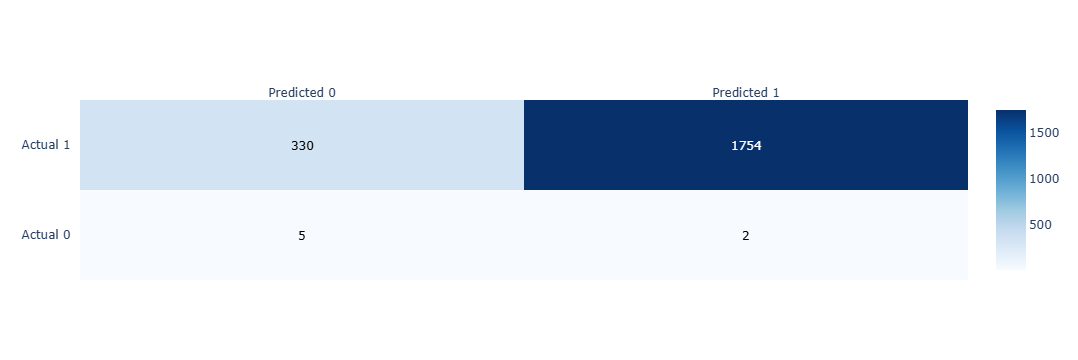


Random Forest - Confusion Matrix
True Positives  (Approved correctly):        2084
False Positives (Denied wrongly approved):   4
True Negatives  (Denied correctly rejected): 3
False Negatives (Approved wrongly rejected): 0


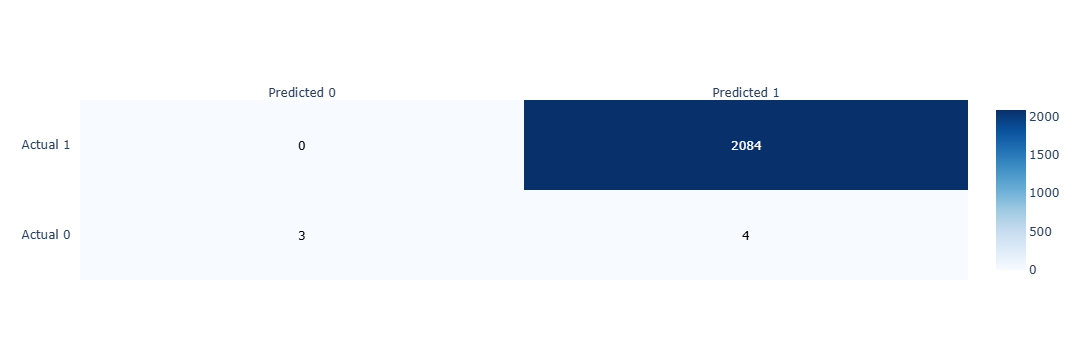


XGBoost - Confusion Matrix
True Positives  (Approved correctly):        2084
False Positives (Denied wrongly approved):   3
True Negatives  (Denied correctly rejected): 4
False Negatives (Approved wrongly rejected): 0


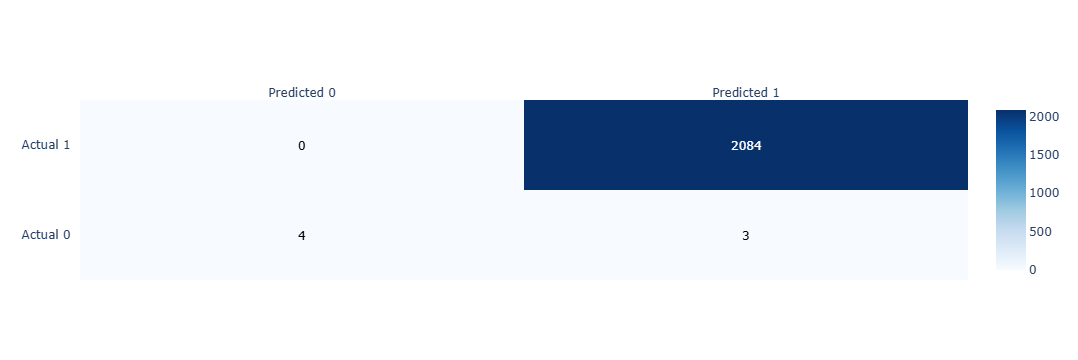

In [30]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xg
}
for name, model in models.items():
    print_confusion_matrix(model, name, X_test, y_test)
   
    